<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 169.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 202.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 116.2 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [4]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [5]:
##Write your code here
df['Industry']= df['Industry'].fillna(df['Industry'].mode()[0])

/tmp/ipykernel_300/739674928.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.values,


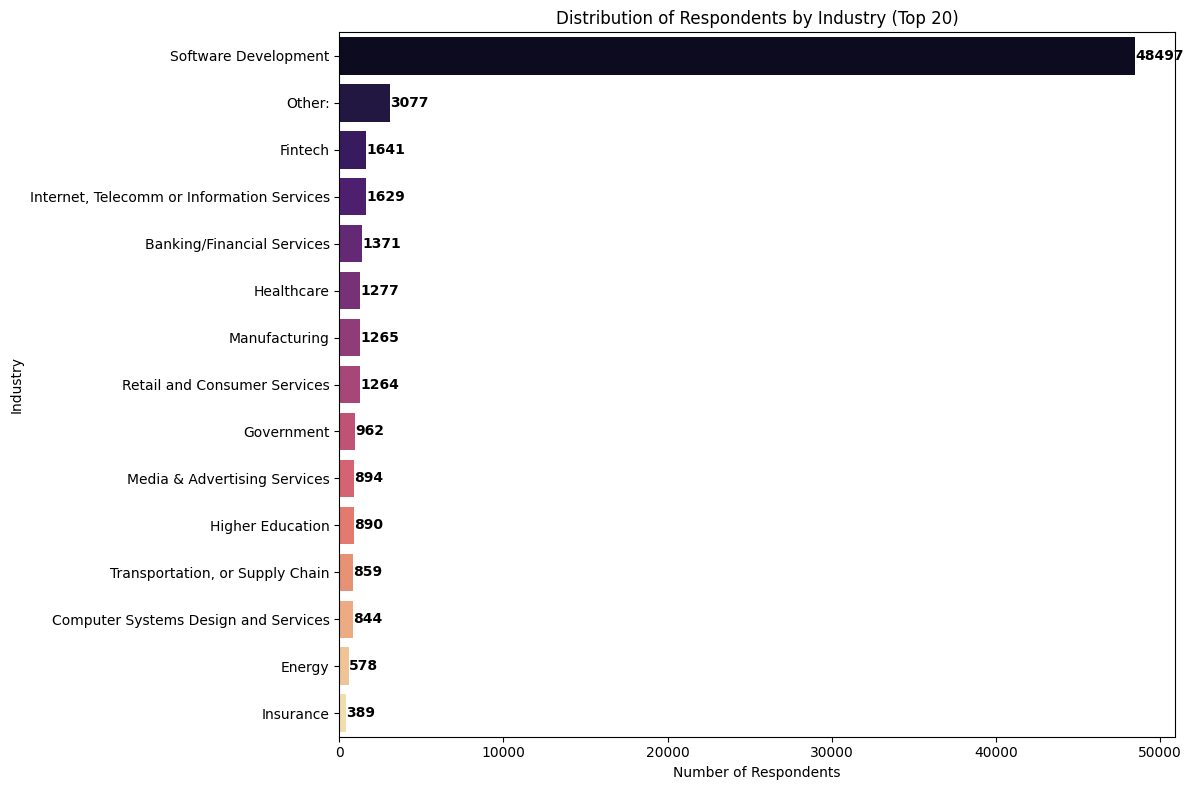

In [6]:
# 1. Calculate the frequency of each industry
industry_counts = df['Industry'].value_counts().head(20)

# 2. Create the horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x=industry_counts.values, 
            y=industry_counts.index, 
            palette='magma')

plt.title('Distribution of Respondents by Industry (Top 20)')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')

# Add data labels to the end of each bar for precision
for i, v in enumerate(industry_counts.values):
    plt.text(v + 3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#The "Information Services, IT specifically, Software Development industry almost always sits at the top. 
#This is the "home" industry for most developers, representing those building the core tools and platforms we use daily.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [7]:
##Write your code here
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"Mean Compensation: ${mean_comp:,.2f}")
print(f"Median Compensation: ${median_comp:,.2f}")
print(f"Standard Deviation: ${std_comp:,.2f}")

Mean Compensation: $86,155.29
Median Compensation: $65,000.00
Standard Deviation: $186,756.97


In [9]:
threshold = mean_comp + (3 * std_comp)

#Identify respondents exceeding this threshold
high_earners = df[df['ConvertedCompYearly'] > threshold]

print(f"Outlier Threshold: ${threshold:,.2f}")
print(f"Number of respondents above threshold: {len(high_earners)}")

# View the top 10 high earners
high_earners[['Country', 'YearsCodePro', 'ConvertedCompYearly']].sort_values('ConvertedCompYearly', ascending=False).head(10)

Outlier Threshold: $646,426.21
Number of respondents above threshold: 89


,Country,YearsCodePro,ConvertedCompYearly
15837,Ethiopia,5,16256603.0
12723,South Africa,10,13818022.0
28379,Taiwan,7,9000000.0
17593,Brazil,13,6340564.0
17672,Ukraine,11,4936778.0
19267,India,7,3367716.0
23694,Pakistan,5,2584118.0
33720,Brazil,5,2237846.0
34523,Pakistan,2,2153432.0
13763,Australia,12,2048046.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [11]:
##Write your code here
#Calculate Q1, Q3, and IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 -Q1 

#Determine lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]

print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f}")
print(f"Upper Bound: ${upper_bound:,.2f}")
print(f"Total number of outliers: {len(outliers)}")


Q1 (25th percentile): $32,712.00
Q3 (75th percentile): $107,971.50
IQR: $75,259.50
Lower Bound: $-80,177.25
Upper Bound: $220,860.75
Total number of outliers: 978


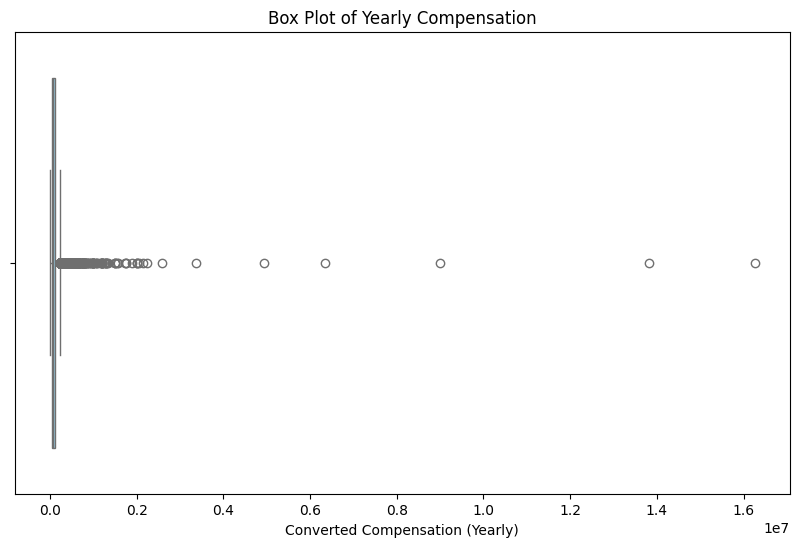

In [12]:
#Visualize with a Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['ConvertedCompYearly'], color='skyblue')
plt.title('Box Plot of Yearly Compensation')
plt.xlabel('Converted Compensation (Yearly)')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [13]:
##Write your code here
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

# Validate the size of the new DataFrame
print(f"Original DataFrame rows: {df.shape[0]}")
print(f"Cleaned DataFrame rows:  {df_no_outliers.shape[0]}")
print(f"Total rows removed:      {df.shape[0] - df_no_outliers.shape[0]}")

Original DataFrame rows: 65437
Cleaned DataFrame rows:  22457
Total rows removed:      42980


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [14]:
##Write your code here
df['Age'].unique()

<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

In [16]:
#The mapping dictionary
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None  # This will become a NaN
}

# Apply the mapping
df['Age_Numeric'] = df['Age'].map(age_mapping)
df['Age_Numeric'].unique()

array([15., 40., 50., 21., 30., 60., nan, 70.])

In [17]:
numeric_columns = df.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_columns.corr()

# Display the correlations specifically for Age
print("Correlation of Age with other variables:")
print(corr_matrix['Age_Numeric'].sort_values(ascending=False))

Correlation of Age with other variables:
Age_Numeric            1.000000
WorkExp                0.848567
ConvertedCompYearly    0.122167
JobSat                 0.069753
CompTotal             -0.002695
JobSatPoints_1        -0.027608
ResponseId            -0.038275
JobSatPoints_8        -0.046113
JobSatPoints_6        -0.049930
JobSatPoints_4        -0.076200
JobSatPoints_9        -0.081717
JobSatPoints_7        -0.083166
JobSatPoints_5        -0.101506
JobSatPoints_11       -0.107109
JobSatPoints_10       -0.114556
Name: Age_Numeric, dtype: float64


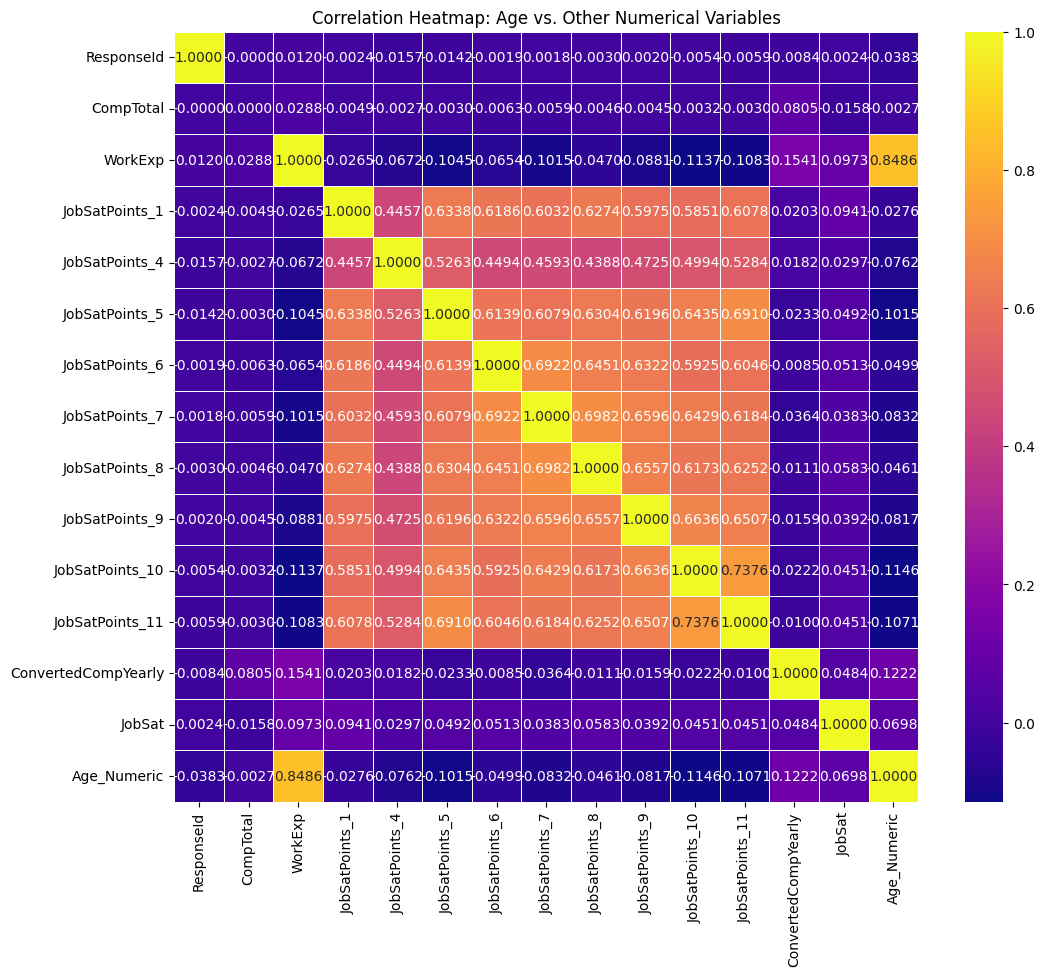

In [20]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='plasma', fmt=".4f", linewidths=0.5)
plt.title('Correlation Heatmap: Age vs. Other Numerical Variables')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
